In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/markdaniellampa/fish-dataset/FishImgDataset/val/Jaguar Gapote/Picture1282.jpg
/kaggle/input/datasets/markdaniellampa/fish-dataset/FishImgDataset/val/Jaguar Gapote/Jaguar Gapote 2.jpg
/kaggle/input/datasets/markdaniellampa/fish-dataset/FishImgDataset/val/Jaguar Gapote/Jaguar Gapote 41.jpg
/kaggle/input/datasets/markdaniellampa/fish-dataset/FishImgDataset/val/Jaguar Gapote/Picture1295.jpg
/kaggle/input/datasets/markdaniellampa/fish-dataset/FishImgDataset/val/Jaguar Gapote/Picture1288.jpg
/kaggle/input/datasets/markdaniellampa/fish-dataset/FishImgDataset/val/Jaguar Gapote/Picture1154.jpg
/kaggle/input/datasets/markdaniellampa/fish-dataset/FishImgDataset/val/Jaguar Gapote/Picture1207.jpg
/kaggle/input/datasets/markdaniellampa/fish-dataset/FishImgDataset/val/Jaguar Gapote/Picture1152.jpg
/kaggle/input/datasets/markdaniellampa/fish-dataset/FishImgDataset/val/Jaguar Gapote/Picture1149.jpg
/kaggle/input/datasets/markdaniellampa/fish-dataset/FishImgDataset/val/Jaguar Gapo

In [7]:
import os
import shutil
from tqdm import tqdm

# ============== PATHS (EDIT IF NEEDED) =================
third_dataset_train = "/kaggle/input/datasets/subirbiswas19/freshwater-fish-disease-aquaculture-in-south-asia/Freshwater Fish Disease Aquaculture in south asia/Train"

first_healthy = "/kaggle/input/datasets/alaamahmoud2010/fish-disease/Fish Disease Dataset/FreshFish"
second_healthy = "/kaggle/input/datasets/utpolkantidas/fresh-water-fish-disease-dataset/Fresh Water Fish Dataset/Healthy Fish"

output_train = "new_fish_dataset/Train"
# ======================================================


def copy_entire_third_dataset():
    if os.path.exists(output_train):
        shutil.rmtree(output_train)
    shutil.copytree(third_dataset_train, output_train)


def copy_images(src, dst, prefix):
    os.makedirs(dst, exist_ok=True)
    images = [f for f in os.listdir(src)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for img in tqdm(images, desc=f"Adding {src}"):
        src_path = os.path.join(src, img)
        dst_path = os.path.join(dst, f"{prefix}_{img}")
        shutil.copy2(src_path, dst_path)


# 1️⃣ Copy all classes from THIRD dataset
print("📦 Copying all classes from third dataset...")
copy_entire_third_dataset()

# 2️⃣ Enrich Healthy class only
healthy_dst = os.path.join(output_train, "Healthy Fish")

print("➕ Adding FreshFish → Healthy Fish")
copy_images(first_healthy, healthy_dst, "fresh")

print("➕ Adding Healthy Fish (second dataset) → Healthy Fish")
copy_images(second_healthy, healthy_dst, "healthy")

copy_images("/kaggle/input/datasets/knowledgelovers/healthy", healthy_dst, "new")

print("\n✅ New dataset created successfully at: new_fish_dataset")

📦 Copying all classes from third dataset...
➕ Adding FreshFish → Healthy Fish


Adding /kaggle/input/datasets/alaamahmoud2010/fish-disease/Fish Disease Dataset/FreshFish: 100%|██████████| 163/163 [00:01<00:00, 136.73it/s]


➕ Adding Healthy Fish (second dataset) → Healthy Fish


Adding /kaggle/input/datasets/utpolkantidas/fresh-water-fish-disease-dataset/Fresh Water Fish Dataset/Healthy Fish: 100%|██████████| 31/31 [00:00<00:00, 193.74it/s]
Adding /kaggle/input/datasets/knowledgelovers/healthy: 100%|██████████| 7/7 [00:00<00:00, 332.73it/s]


✅ New dataset created successfully at: new_fish_dataset


In [18]:
copy_images("/kaggle/input/datasets/knowledgelovers/fungal", "/kaggle/working/new_fish_dataset/Train/Fungal diseases Saprolegniasis", "new")

Adding /kaggle/input/datasets/knowledgelovers/fungal: 100%|██████████| 6/6 [00:00<00:00, 301.09it/s]


In [ ]:
copy_images("/kaggle/input/datasets/knowledgelovers/healthy-fish", healthy_dst, "new")

In [19]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
import os


train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(
        size=224, 
        scale=(0.7, 1.0),   # zoom-in/out
        ratio=(0.75, 1.33)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


train_data = datasets.ImageFolder('/kaggle/working/new_fish_dataset/Train', transform=train_transforms)
test_data = datasets.ImageFolder('/kaggle/input/datasets/subirbiswas19/freshwater-fish-disease-aquaculture-in-south-asia/Freshwater Fish Disease Aquaculture in south asia/Test', transform=test_transforms)

train_data_loader = DataLoader(train_data, batch_size=16, shuffle=True, num_workers=2)
test_data_loader = DataLoader(test_data, batch_size=16, shuffle=False, num_workers=2)

print(f"Training samples: {len(train_data)}")
print(f"Testing samples: {len(test_data)}")

Training samples: 1960
Testing samples: 700


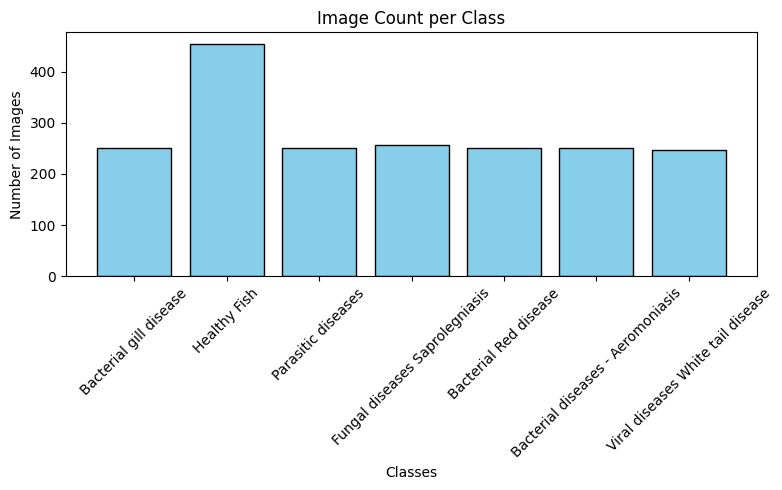

In [20]:
import os
import matplotlib.pyplot as plt

def plot_class_distribution(data_dir):

    
    class_counts = {}
    
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            num_images = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])
            class_counts[class_name] = num_images

   
    plt.figure(figsize=(8, 5))
    plt.bar(class_counts.keys(), class_counts.values(), color='skyblue', edgecolor='black')
    plt.xlabel("Classes")
    plt.ylabel("Number of Images")
    plt.title("Image Count per Class")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_class_distribution("/kaggle/working/new_fish_dataset/Train")

In [8]:
print(len(os.listdir("/kaggle/input/datasets/subirbiswas19/freshwater-fish-disease-aquaculture-in-south-asia/Freshwater Fish Disease Aquaculture in south asia/Train")))

7


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import matplotlib.pyplot as plt

lr = 8.083031267478023e-05

dropout = 0.3006558931441291
num_epochs = 10

model = models.resnet18(pretrained=True)
model.fc = nn.Sequential(
    nn.Dropout(dropout),
    nn.Linear(model.fc.in_features, 7)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=lr,
    weight_decay=1e-4
)

train_losses, val_losses = [], []
train_accs, val_accs = [], []


for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    total, correct = 0, 0

    for images, labels in train_data_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_data_loader.dataset)
    epoch_acc = correct / total

    model.eval()
    correct, total = 0, 0
    test_loss = 0.0

    with torch.no_grad():
        for images, labels in test_data_loader:
            
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    test_epoch_loss = test_loss / len(test_data_loader.dataset)
    test_accuracy = correct / total

  
    train_losses.append(epoch_loss)
    val_losses.append(test_epoch_loss)
    train_accs.append(epoch_acc)
    val_accs.append(test_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f} | "
          f"Val Loss: {test_epoch_loss:.4f}, Val Acc: {test_accuracy:.4f}")
    torch.save({
    "epoch": {epoch},
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "loss": loss,
}, "checkpoint.pth")


torch.save({
    "epoch": num_epochs,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "loss": loss,
}, "checkpoint.pth")

torch.save(model.state_dict(), "Fish_disease.pth")


Epoch [1/10] Train Loss: 1.3764, Train Acc: 0.4918 | Val Loss: 0.8331, Val Acc: 0.7314
Epoch [2/10] Train Loss: 0.7771, Train Acc: 0.7383 | Val Loss: 0.5948, Val Acc: 0.8000
Epoch [3/10] Train Loss: 0.5740, Train Acc: 0.8199 | Val Loss: 0.2888, Val Acc: 0.9314
Epoch [4/10] Train Loss: 0.4410, Train Acc: 0.8500 | Val Loss: 0.2339, Val Acc: 0.9429
Epoch [5/10] Train Loss: 0.3546, Train Acc: 0.8806 | Val Loss: 0.1539, Val Acc: 0.9614
Epoch [6/10] Train Loss: 0.2931, Train Acc: 0.9066 | Val Loss: 0.1349, Val Acc: 0.9614
Epoch [7/10] Train Loss: 0.2387, Train Acc: 0.9255 | Val Loss: 0.1079, Val Acc: 0.9729
Epoch [8/10] Train Loss: 0.2108, Train Acc: 0.9316 | Val Loss: 0.1146, Val Acc: 0.9643
Epoch [9/10] Train Loss: 0.2094, Train Acc: 0.9383 | Val Loss: 0.0750, Val Acc: 0.9800
Epoch [10/10] Train Loss: 0.1800, Train Acc: 0.9398 | Val Loss: 0.0585, Val Acc: 0.9829


In [ ]:

num_epochs = 20;

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    total, correct = 0, 0

    for images, labels in train_data_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_data_loader.dataset)
    epoch_acc = correct / total

    model.eval()
    correct, total = 0, 0
    test_loss = 0.0

    with torch.no_grad():
        for images, labels in test_data_loader:
            
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    test_epoch_loss = test_loss / len(test_data_loader.dataset)
    test_accuracy = correct / total

  
    train_losses.append(epoch_loss)
    val_losses.append(test_epoch_loss)
    train_accs.append(epoch_acc)
    val_accs.append(test_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f} | "
          f"Val Loss: {test_epoch_loss:.4f}, Val Acc: {test_accuracy:.4f}")
    torch.save({
    "epoch": {epoch},
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "loss": loss,
}, "checkpoint.pth")


torch.save({
    "epoch": num_epochs,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "loss": loss,
}, "checkpoint.pth")

torch.save(model.state_dict(), "Fish.pth")


In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import os

# -------- CONFIG --------
MODEL_PATH = "model.pth"
IMAGE_PATH = "test.jpg"
DATASET_DIR = "new_fish_dataset/Train"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 256
# ------------------------

# Load class names (same order as training)
class_names = sorted(os.listdir(DATASET_DIR))

# # Load model
# model = torch.load(MODEL_PATH, map_location=DEVICE)
# model.eval().to(DEVICE)

# Image preprocessing (match training)
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load image
image = Image.open(IMAGE_PATH).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(DEVICE)

# Inference
with torch.no_grad():
    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1)
    pred_idx = probs.argmax(dim=1).item()

# Output
print("Predicted class:", class_names[pred_idx])
print("Confidence:", probs[0][pred_idx].item())

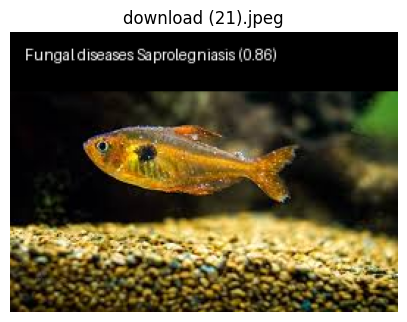

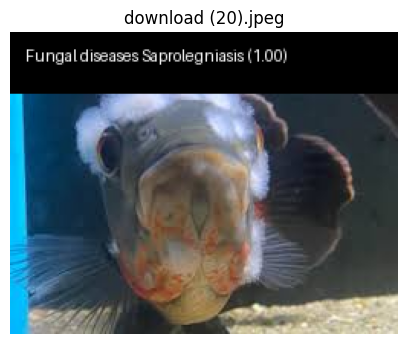

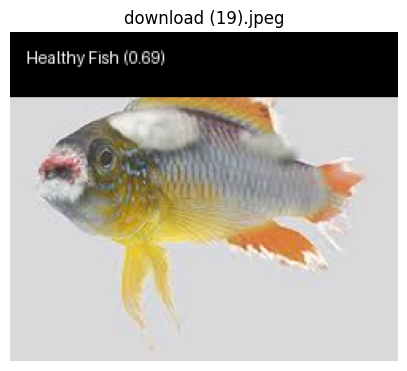

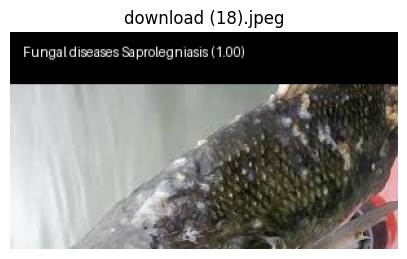

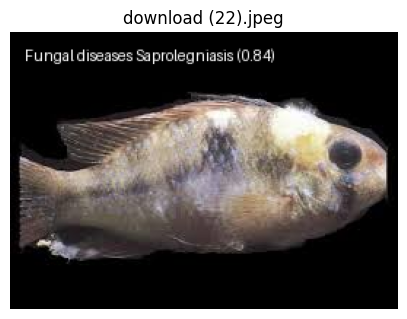

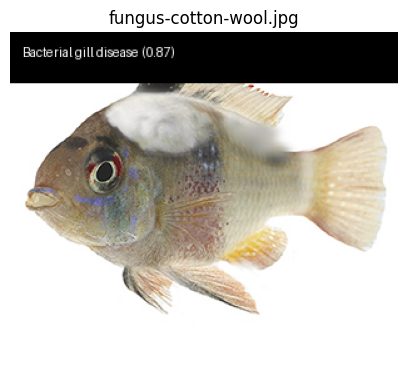

In [23]:
import torch
from torchvision import transforms
from PIL import Image, ImageDraw, ImageFont
import os
import matplotlib.pyplot as plt

# ------------ CONFIG ------------
MODEL_PATH = "model.pth"
TEST_DIR = "/kaggle/input/datasets/knowledgelovers/fungal"
TRAIN_DIR = "new_fish_dataset/Train"
IMG_SIZE = 224
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# --------------------------------

# Load class names
class_names = sorted(os.listdir(TRAIN_DIR))

# # Load model
# model = torch.load(MODEL_PATH, map_location=DEVICE)
# model.eval().to(DEVICE)

# Image transform
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Loop through test images
for img_name in os.listdir(TEST_DIR):
    if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue

    img_path = os.path.join(TEST_DIR, img_name)

    # Load image
    image = Image.open(img_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(DEVICE)

    # Inference
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = probs.argmax(dim=1).item()
        confidence = probs[0][pred_idx].item()

    pred_class = class_names[pred_idx]

    # Draw prediction on image
    draw = ImageDraw.Draw(image)
    text = f"{pred_class} ({confidence:.2f})"
    draw.rectangle([0, 0, 420, 40], fill=(0, 0, 0))
    draw.text((10, 10), text, fill=(255, 255, 255))

    # Show image
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(img_name)
    plt.show()

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, test_loader, device, class_names=None):
    model.eval()
    
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    cm = confusion_matrix(all_labels, all_preds)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    plt.figure(figsize=(16, 16))
    disp.plot(cmap="Blues", values_format="d")
    plt.title("Confusion Matrix")
    plt.show()
    

In [ ]:

all_labels = []

for _, labels in test_data_loader:
    all_labels.append(labels)

all_labels = torch.cat(all_labels)

print("Test labels info:")
print("  dtype      :", all_labels.dtype)
print("  min label  :", all_labels.min().item())
print("  max label  :", all_labels.max().item())
print("  unique     :", torch.unique(all_labels))
print("  num unique :", len(torch.unique(all_labels)))

In [ ]:
import torch
import random
from collections import Counter

# =========================
# CONFIG
# =========================
NUM_SAMPLES = 100
NUM_CLASSES = 8   # must match model.fc output

model.eval()

# =========================
# 1. COLLECT FULL TEST SET
# =========================
all_images = []
all_labels = []

for images, labels in test_data_loader:
    all_images.append(images)
    all_labels.append(labels)

all_images = torch.cat(all_images)
all_labels = torch.cat(all_labels)

print("\n========== DATASET SANITY CHECK ==========")
print("Total test samples :", len(all_labels))
print("Label dtype        :", all_labels.dtype)
print("Min label          :", all_labels.min().item())
print("Max label          :", all_labels.max().item())
print("Unique labels      :", torch.unique(all_labels))
print("Num unique labels  :", len(torch.unique(all_labels)))


# =========================
# 2. CLASS DISTRIBUTION
# =========================
label_counter = Counter(all_labels.cpu().numpy())

print("\n========== CLASS DISTRIBUTION ==========")
for k in sorted(label_counter):
    print(f"Class {k}: {label_counter[k]} samples")

# =========================
# 3. RANDOM 100 SAMPLE TEST
# =========================
indices = random.sample(range(len(all_labels)), min(NUM_SAMPLES, len(all_labels)))

sample_images = all_images[indices].to(device)
sample_labels = all_labels[indices].to(device).long()

with torch.no_grad():
    outputs = model(sample_images)
    probs = torch.softmax(outputs, dim=1)
    preds = torch.argmax(outputs, dim=1)

correct = (preds == sample_labels).sum().item()
accuracy = correct / len(indices)

print("\n========== RANDOM SAMPLE EVALUATION ==========")
print(f"Accuracy on {len(indices)} random samples: {accuracy:.4f}")

# =========================
# 4. PRINT PREDICTIONS
# =========================
print("\nIndex | True Label | Predicted | Confidence")
print("-" * 50)

for i in range(len(indices)):
    conf = probs[i, preds[i]].item()
    print(f"{i:5d} | {sample_labels[i].item():10d} | "
          f"{preds[i].item():9d} | {conf:.4f}")

# =========================
# 5. MISMATCHES ONLY
# =========================
print("\n========== MISMATCHES ==========")
mismatch_count = 0

for i in range(len(indices)):
    if preds[i] != sample_labels[i]:
        mismatch_count += 1
        print(f"Idx {i}: True={sample_labels[i].item()} "
              f"Pred={preds[i].item()} "
              f"Conf={probs[i, preds[i]].item():.4f}")

print(f"\nTotal mismatches: {mismatch_count}/{len(indices)}")

print("\n========== PREDICTION CHECK ==========")
print("Unique predictions:", torch.unique(preds))

In [ ]:

epochs = range(1, num_epochs + 1)
plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, marker='o', label='Train Loss')
plt.plot(epochs, val_losses, marker='o', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, marker='o', label='Train Accuracy')
plt.plot(epochs, val_accs, marker='o', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

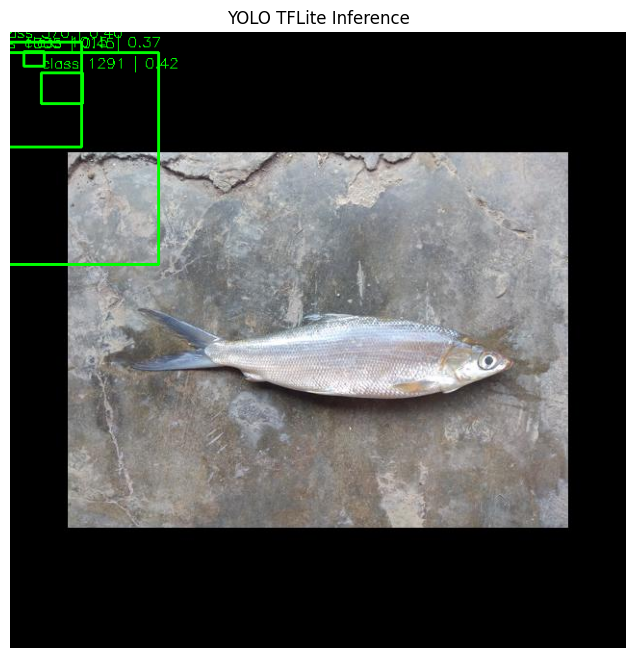

In [10]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
TFLITE_MODEL = "/kaggle/input/models/knowledgelovers/quantized-yolos/pytorch/default/1/detection_float32.tflite"
IMAGE_PATH = "/kaggle/input/datasets/knowledgelovers/fish-yolo/train/images/IMG_20190930_071328_png.rf.c390349397ed5f420b153003e295a59f.jpg"

IMG_SIZE = 256
CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.45

# ---------------- UTILS ----------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def iou(box1, box2):
    x1, y1, x2, y2 = box1
    x1b, y1b, x2b, y2b = box2

    xi1 = max(x1, x1b)
    yi1 = max(y1, y1b)
    xi2 = min(x2, x2b)
    yi2 = min(y2, y2b)

    inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    area1 = (x2 - x1) * (y2 - y1)
    area2 = (x2b - x1b) * (y2b - y1b)

    union = area1 + area2 - inter
    return inter / union if union > 0 else 0

def nms(boxes, scores, iou_thr):
    idxs = np.argsort(scores)[::-1]
    keep = []

    while len(idxs) > 0:
        current = idxs[0]
        keep.append(current)
        idxs = idxs[1:]

        idxs = np.array([
            i for i in idxs
            if iou(boxes[current], boxes[i]) < iou_thr
        ])

    return keep

# ---------------- LOAD MODEL ----------------
interpreter = tf.lite.Interpreter(model_path=TFLITE_MODEL)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# ---------------- PREPROCESS ----------------
orig_img = cv2.imread(IMAGE_PATH)
orig_h, orig_w, _ = orig_img.shape

img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img = img.astype(np.float32) / 255.0
input_tensor = np.expand_dims(img, axis=0)

interpreter.set_tensor(input_details[0]["index"], input_tensor)

# ---------------- INFERENCE ----------------
interpreter.invoke()
output = interpreter.get_tensor(output_details[0]["index"])[0]

# ---------------- POSTPROCESS ----------------
boxes = []
scores = []
classes = []

for det in output:
    cx, cy, w, h = det[:4]
    obj = sigmoid(det[4])
    cls_scores = sigmoid(det[5:])

    cls_id = np.argmax(cls_scores)
    cls_conf = cls_scores[cls_id]
    conf = obj * cls_conf

    if conf < CONF_THRESHOLD:
        continue

    # convert to pixel coords
    x1 = int((cx - w / 2) * orig_w)
    y1 = int((cy - h / 2) * orig_h)
    x2 = int((cx + w / 2) * orig_w)
    y2 = int((cy + h / 2) * orig_h)

    boxes.append([x1, y1, x2, y2])
    scores.append(conf)
    classes.append(cls_id)

# ---------------- NMS ----------------
keep = nms(boxes, scores, IOU_THRESHOLD)

# ---------------- VISUALIZE ----------------
for i in keep:
    x1, y1, x2, y2 = boxes[i]
    conf = scores[i]
    cls = classes[i]

    cv2.rectangle(orig_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(
        orig_img,
        f"class {cls} | {conf:.2f}",
        (x1, y1 - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1
    )

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("YOLO TFLite Inference")
plt.show()

In [7]:
print(input_details)

[{'name': 'serving_default_images:0', 'index': 0, 'shape': array([  1, 256, 256,   3], dtype=int32), 'shape_signature': array([  1, 256, 256,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


In [8]:
print(output_details)

[{'name': 'PartitionedCall:0', 'index': 419, 'shape': array([   1,    8, 1344], dtype=int32), 'shape_signature': array([   1,    8, 1344], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


In [6]:
import shutil

src = "/kaggle/input/models/knowledgelovers/fish-models/pytorch/default/1/Fish_disease.pth"
dst = "fish_disease.pth"

shutil.copy(src, dst)

print("Copied to:", dst)

Copied to: fish_disease.pth


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.


E0000 00:00:1772214992.764502      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772214992.815171      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772214993.224048      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772214993.224102      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772214993.224108      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772214993.224112      55 computation_placer.cc:177] computation placer already registered. Please check linka

Loading /kaggle/input/models/knowledgelovers/quantized-yolos/pytorch/default/1/detection_float32.tflite for TensorFlow Lite inference...



/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


image 1/1 /kaggle/input/datasets/knowledgelovers/fish-test/412YOMx098L._AC.jpg: 256x256 5 1s, 1 2, 31.4ms
Speed: 28.8ms preprocess, 31.4ms inference, 41.8ms postprocess per image at shape (1, 3, 256, 256)


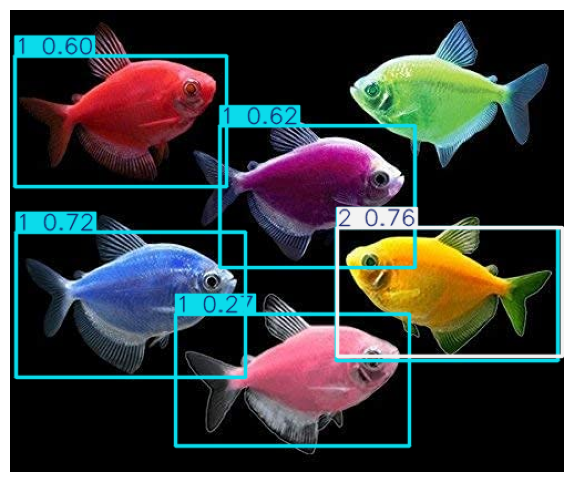

In [3]:


# Load the exported TFLite model
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load TFLite model
tflite_model = YOLO("/kaggle/input/models/knowledgelovers/quantized-yolos/pytorch/default/1/detection_float32.tflite")

# Run inference
results = tflite_model("/kaggle/input/datasets/knowledgelovers/fish-test/412YOMx098L._AC.jpg")

# Plot results (returns annotated image as numpy array, BGR)
annotated_img = results[0].plot()

# Convert BGR -> RGB for matplotlib
annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

# Show
plt.figure(figsize=(10, 6))
plt.imshow(annotated_img)
plt.axis("off")
plt.show()

In [6]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import os

# ---------------- CONFIG ----------------
DEVICE = "cpu"
DROPOUT = 0.3006558931441291
NUM_CLASSES = 7

MODEL_1_PATH = "/kaggle/input/models/knowledgelovers/fish-disease/pytorch/default/1/Fish_disease (1).pth"
MODEL_2_PATH = "/kaggle/input/models/knowledgelovers/fish-models/pytorch/default/1/Fish_disease.pth"

HEALTHY_FOLDER = "/kaggle/input/datasets/knowledgelovers/healthy-fish"  # CHANGE IF NEEDED

CLASS_NAMES = [
    "class_0", "class_1", "class_2",
    "class_3", "class_4", "class_5", "class_6"
]

# ---------------- TRANSFORMS ----------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# ---------------- MODEL LOADER ----------------
def load_model(pth_path):
    model = models.resnet18(weights=None)
    model.fc = nn.Sequential(
        nn.Dropout(DROPOUT),
        nn.Linear(model.fc.in_features, NUM_CLASSES)
    )
    model.load_state_dict(torch.load(pth_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    return model

model_1 = load_model(MODEL_1_PATH)
model_2 = load_model(MODEL_2_PATH)

# ---------------- INFERENCE FUNCTION ----------------
def infer(model, image_path):
    image = Image.open(image_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=1)
        conf, pred = torch.max(probs, dim=1)

    return pred.item(), conf.item(), probs.squeeze().cpu().numpy()

# ---------------- LOOP THROUGH HEALTHY FOLDER ----------------
results = []

for img_name in sorted(os.listdir(HEALTHY_FOLDER)):
    if not img_name.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    img_path = os.path.join(HEALTHY_FOLDER, img_name)

    pred1, conf1, _ = infer(model_1, img_path)
    pred2, conf2, _ = infer(model_2, img_path)

    print(f"\n🖼️ {img_name}")
    print(f"Model-1 → {CLASS_NAMES[pred1]} ({conf1:.3f})")
    print(f"Model-2 → {CLASS_NAMES[pred2]} ({conf2:.3f})")

    results.append({
        "image": img_name,
        "model1_pred": pred1,
        "model1_conf": conf1,
        "model2_pred": pred2,
        "model2_conf": conf2,
    })

print(f"\n✅ Processed {len(results)} healthy images")


🖼️ download (2).jpeg
Model-1 → class_6 (0.546)
Model-2 → class_3 (0.446)

🖼️ download (3).jpeg
Model-1 → class_6 (1.000)
Model-2 → class_6 (1.000)

🖼️ images (1).jpeg
Model-1 → class_4 (0.949)
Model-2 → class_4 (0.767)

🖼️ images (2).jpeg
Model-1 → class_3 (0.659)
Model-2 → class_3 (0.998)

🖼️ images (3).jpeg
Model-1 → class_4 (0.970)
Model-2 → class_4 (0.949)

✅ Processed 5 healthy images


In [7]:
dummy_input = torch.randn(1, 3, 256, 256)

onnx_path = "diease.onnx"

torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=13,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch"},
        "output": {0: "batch"}
    }
)

print("ONNX export done")

/tmp/ipykernel_54/404766095.py:5: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0228 06:23:56.646000 54 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 13 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0228 06:23:57.133000 54 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 

[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 13).
Failed to convert the model to the target version 13 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py"

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 40 of general pattern rewrite rules.
ONNX export done


In [4]:
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 12.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 13.0 MB/s eta 0:00:00


In [7]:
import onnxruntime as ort
import numpy as np
from PIL import Image
from torchvision import transforms

# ---------------- LOAD ONNX MODEL ----------------
session = ort.InferenceSession("/kaggle/input/models/knowledgelovers/quant-fish-askshu/pytorch/default/1/Fish (2).onnx")

# Get correct input name
input_name = session.get_inputs()[0].name
print("ONNX input name:", input_name)

# ---------------- CLASS NAMES ----------------
class_names = [
    "0","1","2","3","4","5", "6"
]

# ---------------- TRANSFORMS ----------------
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ---------------- LOAD & PREPROCESS IMAGE ----------------
img = Image.open(
    "/kaggle/input/datasets/markdaniellampa/fish-dataset/FishImgDataset/train/Catfish/00255ef6-05cd-46d4-8724-694847af29dc-860mm.jpg"
).convert("RGB")

input_tensor = test_transforms(img)           # (3, 256, 256)
input_tensor = input_tensor.unsqueeze(0)      # (1, 3, 256, 256)
input_numpy = input_tensor.numpy()             # ✅ NumPy

# ---------------- RUN INFERENCE ----------------
outputs = session.run(None, {input_name: input_numpy})

logits = outputs[0]
pred_idx = np.argmax(logits, axis=1)[0]

print("Predicted class:", pred_idx)

ONNX input name: input
Predicted class: 3


In [9]:
import tensorflow as tf
import numpy as np
from PIL import Image

# =====================================================
# CONFIG
# =====================================================
TFLITE_MODEL_PATH = "/kaggle/input/models/knowledgelovers/quanti-fish/pytorch/default/1/Fish_float16.tflite"
IMAGE_PATH = "/kaggle/input/datasets/markdaniellampa/fish-dataset/FishImgDataset/train/Bangus/Bangus 1.jpg"
IMG_SIZE = 224
NUM_CLASSES = 31

# =====================================================
# LOAD TFLITE MODEL
# =====================================================
interpreter = tf.lite.Interpreter(model_path=TFLITE_MODEL_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details:", input_details)
print("Output details:", output_details)

# =====================================================
# PREPROCESS (MATCHES PYTORCH TRANSFORMS EXACTLY)
# =====================================================
def preprocess_image(image_path):
    # Load image
    img = Image.open(image_path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))

    # uint8 → float32 → [0, 1]
    img = np.asarray(img, dtype=np.float32) / 255.0

    # ImageNet normalization (PyTorch ResNet)
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    img = (img - mean) / std

    # NHWC + batch dimension
    img = np.expand_dims(img, axis=0)

    # IMPORTANT: keep FLOAT32 (CPU requirement)
    return img

input_data = preprocess_image(IMAGE_PATH)

# Sanity checks
print("Input shape:", input_data.shape)
print("Input dtype:", input_data.dtype)
print("Input min/max:", input_data.min(), input_data.max())

# =====================================================
# RUN INFERENCE
# =====================================================
interpreter.set_tensor(input_details[0]["index"], input_data)
interpreter.invoke()

output = interpreter.get_tensor(output_details[0]["index"])

# =====================================================
# POSTPROCESS
# =====================================================
# If your PyTorch model ended with CrossEntropyLoss (no softmax)
probs = tf.nn.softmax(output).numpy()[0]

pred_class = int(np.argmax(probs))
confidence = float(probs[pred_class])

print(f"\nPredicted class: {pred_class}")
print(f"Confidence: {confidence:.4f}")
print("All class probabilities:", probs)

Input details: [{'name': 'serving_default_input:0', 'index': 0, 'shape': array([  1, 224, 224,   3], dtype=int32), 'shape_signature': array([ -1, 224, 224,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'PartitionedCall:0', 'index': 129, 'shape': array([ 1, 31], dtype=int32), 'shape_signature': array([-1, 31], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Input shape: (1, 224, 224, 3)
Input dtype: float32
Input min/max: -2.117904 2.64

Predicted class: 0
Confidence: 1.0000
All class probabilities: [9.9999797e-01 6.6495680e-08 4.3834403e-09 6.9948143e-08 1.5257513e-08
 1.0006841e-09 4.509888

In [2]:
!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 95.4 MB/s eta 0:00:00:00:010:01


In [22]:
from onnx_tf.backend import prepare
import tensorflow as tf

# Load ONNX model
onnx_model_path = "fish.onnx"
tf_model_path = "fish_tf"

onnx_model = onnx.load(onnx_model_path)
tf_rep = prepare(onnx_model)

# Export TensorFlow SavedModel
tf_rep.export_graph(tf_model_path)

print("✅ TensorFlow model saved")

ModuleNotFoundError: No module named 'tensorflow_addons'

In [6]:
!pip  install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.6 MB/s eta 0:00:0000:01


In [3]:
!pip install tf2onnx

INFO: pip is looking at multiple versions of onnx to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 101.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 13.5 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: onnx
    Found existing installation: onnx 1.20.1
    Uninstalling onnx-1.20.1:
      Successfully uninstalled onnx-1.20.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.21.0 requires 

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.4 MB/s eta 0:00:00a 0:00:01
